In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

#### Load cleaned data

In [122]:
df = pd.read_csv('data/f1_laps_clean.csv')

In [123]:
df.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Stint', 'LapTime', 'LapNumber',
       'Position', 'Compound', 'TyreLife', 'FreshTyre', 'TrackStatus',
       'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp',
       'WindDirection', 'WindSpeed', 'Speed_Mean', 'Speed_Max', 'Speed_Std',
       'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'Gear_Mean',
       'Distance_Total', 'DRS_active_pct', 'LapsTilPit'],
      dtype='object')

#### Encode and standardize features

In [124]:
df.dtypes

Driver             object
Team               object
Year                int64
Race               object
Stint             float64
LapTime            object
LapNumber         float64
Position          float64
Compound           object
TyreLife          float64
FreshTyre            bool
TrackStatus         int64
AirTemp           float64
Humidity          float64
Pressure          float64
Rainfall             bool
TrackTemp         float64
WindDirection     float64
WindSpeed         float64
Speed_Mean        float64
Speed_Max         float64
Speed_Std         float64
RPM_Mean          float64
Throttle_Mean     float64
Throttle_Std      float64
Brake_Mean        float64
Gear_Mean         float64
Distance_Total    float64
DRS_active_pct    float64
LapsTilPit        float64
dtype: object

In [125]:
# Turn bool values into int
df['FreshTyre'] = df['FreshTyre'].astype(int)
df['Rainfall'] = df['Rainfall'].astype(int)

In [126]:
ordinal_cols = ['Stint', 'Position']  # leave as is
label = ['LapsTilPit']

label_encode_cols = ['Driver', 'Team', 'Race', 'TrackStatus']
one_hot_cols = ['Compound']

numerical_cols = ['LapTimeSeconds', 'LapNumber', 'TyreLife',
       'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 'WindSpeed',
       'Speed_Mean', 'Speed_Max', 'Speed_Std', 'Throttle_Mean', 'Throttle_Std',
       'RPM_Mean', 'Brake_Mean', 'Gear_Mean', 'Distance_Total', 'DRS_active_pct']

In [127]:
df_encoded = df.copy()

In [128]:
# Apply cyclical encoding
df_encoded['WindDir_sin'] = np.sin(np.deg2rad(df_encoded['WindDirection']))
df_encoded['WindDir_cos'] = np.cos(np.deg2rad(df_encoded['WindDirection']))

df_encoded = df_encoded.drop(columns=['WindDirection'])

In [129]:
# Label encode
for col in label_encode_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

In [130]:
# One-hot encode
df_encoded = pd.get_dummies(df_encoded, columns=one_hot_cols, drop_first=False)

# Find all new columns created by one-hot encoding
new_cols = [col for col in df_encoded.columns if any(prefix + '_' in col for prefix in one_hot_cols)]

# Cast these columns to int (0/1)
df_encoded[new_cols] = df_encoded[new_cols].astype(int)

In [131]:
df_encoded.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Stint', 'LapTime', 'LapNumber',
       'Position', 'TyreLife', 'FreshTyre', 'TrackStatus', 'AirTemp',
       'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindSpeed',
       'Speed_Mean', 'Speed_Max', 'Speed_Std', 'RPM_Mean', 'Throttle_Mean',
       'Throttle_Std', 'Brake_Mean', 'Gear_Mean', 'Distance_Total',
       'DRS_active_pct', 'LapsTilPit', 'WindDir_sin', 'WindDir_cos',
       'Compound_HARD', 'Compound_INTERMEDIATE', 'Compound_MEDIUM',
       'Compound_SOFT', 'Compound_WET'],
      dtype='object')

In [132]:
df_encoded.loc[0]

Driver                                       28
Team                                         11
Year                                       2022
Race                                          4
Stint                                       1.0
LapTime                  0 days 00:01:40.236000
LapNumber                                   1.0
Position                                    2.0
TyreLife                                    4.0
FreshTyre                                     0
TrackStatus                                   0
AirTemp                                    23.9
Humidity                                   25.0
Pressure                                 1010.2
Rainfall                                      0
TrackTemp                                  29.1
WindSpeed                                   0.5
Speed_Mean                           183.433962
Speed_Max                                 286.0
Speed_Std                             66.059742
RPM_Mean                           10247

In [133]:
# Convert LapTime to seconds
df_encoded['LapTimeSeconds'] = pd.to_timedelta(df_encoded['LapTime']).dt.total_seconds()
df_encoded = df_encoded.drop(columns=['LapTime'])

df_encoded['LapTimeSeconds']

0        100.236
1        101.006
2        108.826
3        104.270
4        101.555
          ...   
82196     79.675
82197     80.110
82198     79.899
82199     81.201
82200     79.978
Name: LapTimeSeconds, Length: 82201, dtype: float64

In [134]:
# Standardize numerical columns
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

In [135]:
df_encoded[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LapTimeSeconds,82201.0,1.174715e-16,1.000006,-0.701046,-0.294124,-0.055866,0.183963,67.107506
LapNumber,82201.0,3.457587e-17,1.000006,-1.617451,-0.851054,-0.029914,0.791225,2.597733
TyreLife,82201.0,-1.936249e-17,1.000006,-1.286066,-0.810355,-0.239501,0.521637,6.039890
AirTemp,82201.0,2.814476e-16,1.000006,-2.278857,-0.759499,0.020711,0.780390,2.710385
Humidity,82201.0,-3.595890e-17,1.000006,-2.823568,-0.709306,0.054178,0.700202,2.285899
Pressure,82201.0,1.241447e-15,1.000006,-3.978485,0.059582,0.403247,0.498710,0.647632
TrackTemp,82201.0,-5.788000e-16,1.000006,-2.277085,-0.663041,-0.005895,0.812656,2.553517
WindSpeed,82201.0,-1.369204e-16,1.000006,-1.601962,-0.647873,-0.214196,0.479687,5.857279
Speed_Mean,82201.0,5.393835e-16,1.000006,-7.288203,-0.464626,0.117173,0.699305,2.159354
Speed_Max,82201.0,1.372662e-16,1.000006,-15.984814,-0.460718,-0.046742,0.625969,3.109825


#### Split into train, val, and test sets

In [136]:
# Train, val, test split
train_df = df_encoded[df_encoded['Year'].isin([2022, 2023])]
val_df   = df_encoded[df_encoded['Year'] == 2024]
test_df  = df_encoded[df_encoded['Year'] == 2025]

In [137]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(47033, 35)
(26381, 35)
(8787, 35)


In [138]:
# Split sets into features and target
feature_cols = [col for col in train_df.columns if col not in ['LapsTilPit', 'Year']]

# Training set
X_train = train_df[feature_cols]
y_train = train_df['LapsTilPit']

# Validation set
X_val = val_df[feature_cols]
y_val = val_df['LapsTilPit']

# Test set
X_test = test_df[feature_cols]
y_test = test_df['LapsTilPit']

In [139]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(47033, 33)
(47033,)
(26381, 33)
(26381,)
(8787, 33)
(8787,)


#### Train XGBoost regression model

In [140]:
# Train XGBoost regressor
xgb_reg = XGBRegressor()
xgb_reg.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True)

[0]	validation_0-rmse:10.26867
[1]	validation_0-rmse:9.68817
[2]	validation_0-rmse:9.33678
[3]	validation_0-rmse:9.10707
[4]	validation_0-rmse:8.92942
[5]	validation_0-rmse:8.90573
[6]	validation_0-rmse:8.86303
[7]	validation_0-rmse:8.83758
[8]	validation_0-rmse:8.78527
[9]	validation_0-rmse:8.76077
[10]	validation_0-rmse:8.71066
[11]	validation_0-rmse:8.70506
[12]	validation_0-rmse:8.69489
[13]	validation_0-rmse:8.67461
[14]	validation_0-rmse:8.70617
[15]	validation_0-rmse:8.67212
[16]	validation_0-rmse:8.67028
[17]	validation_0-rmse:8.67859
[18]	validation_0-rmse:8.78672
[19]	validation_0-rmse:8.79850
[20]	validation_0-rmse:8.80111
[21]	validation_0-rmse:8.82755
[22]	validation_0-rmse:8.93737
[23]	validation_0-rmse:8.94965
[24]	validation_0-rmse:8.95240
[25]	validation_0-rmse:8.95765
[26]	validation_0-rmse:8.98789
[27]	validation_0-rmse:9.19273
[28]	validation_0-rmse:9.21893
[29]	validation_0-rmse:9.21412
[30]	validation_0-rmse:9.20625
[31]	validation_0-rmse:9.21687
[32]	validation_0

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [141]:
# Predict
y_val_pred = xgb_reg.predict(X_val)
y_test_pred = xgb_reg.predict(X_test)

# Evaluate
print("Validation Results:")
print(f"RMSE: {root_mean_squared_error(y_val, y_val_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred):.3f}")
print(f"R2:   {r2_score(y_val, y_val_pred):.3f}")

print("\nTest Results:")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred):.3f}")
print(f"R2:   {r2_score(y_test, y_test_pred):.3f}")

Validation Results:
RMSE: 9.658
MAE:  6.962
R2:   0.254

Test Results:
RMSE: 9.406
MAE:  6.995
R2:   0.183


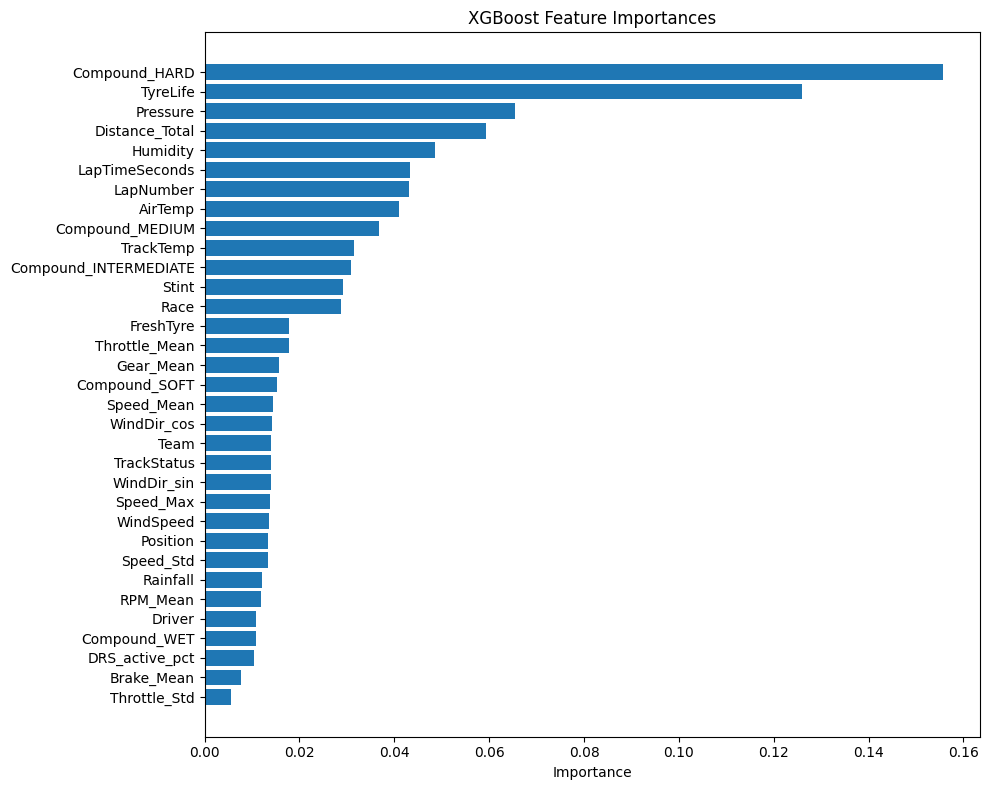

In [142]:
# Get feature importances and sort them
importances = xgb_reg.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.barh(np.array(X_train.columns)[indices], importances[indices])
plt.title("XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#### Tune regression model

In [143]:
# Set up parameter grid
param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0]
}

In [144]:
# Set up RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_dist,
    n_iter=50,  # number of parameter settings sampled
    scoring='neg_root_mean_squared_error',  # for RMSE
    cv=3,
    verbose=1,
    random_state=111,
    n_jobs=-1
)

# Fit on data
search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 6, 8, 10],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 500],
                                        'reg_alpha': [0, 0.1, 0.5, 1.0],
                                        'reg_lambda': [0.5, 1.0, 2.0],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=111, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [145]:
best_xgb = search.best_estimator_

print("Best parameters:", search.best_params_)

# Evaluate on validation and test
y_val_pred_tuned = best_xgb.predict(X_val)
y_test_pred_tuned = best_xgb.predict(X_test)

print("Validation Results:")
print(f"RMSE: {root_mean_squared_error(y_val, y_val_pred_tuned):.3f}")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_tuned):.3f}")
print(f"R2:   {r2_score(y_val, y_val_pred_tuned):.3f}")

print("\nTest Results:")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred_tuned):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_tuned):.3f}")
print(f"R2:   {r2_score(y_test, y_test_pred_tuned):.3f}")

Best parameters: {'subsample': 0.6, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Validation Results:
RMSE: 8.806
MAE:  6.376
R2:   0.380

Test Results:
RMSE: 8.791
MAE:  6.493
R2:   0.287


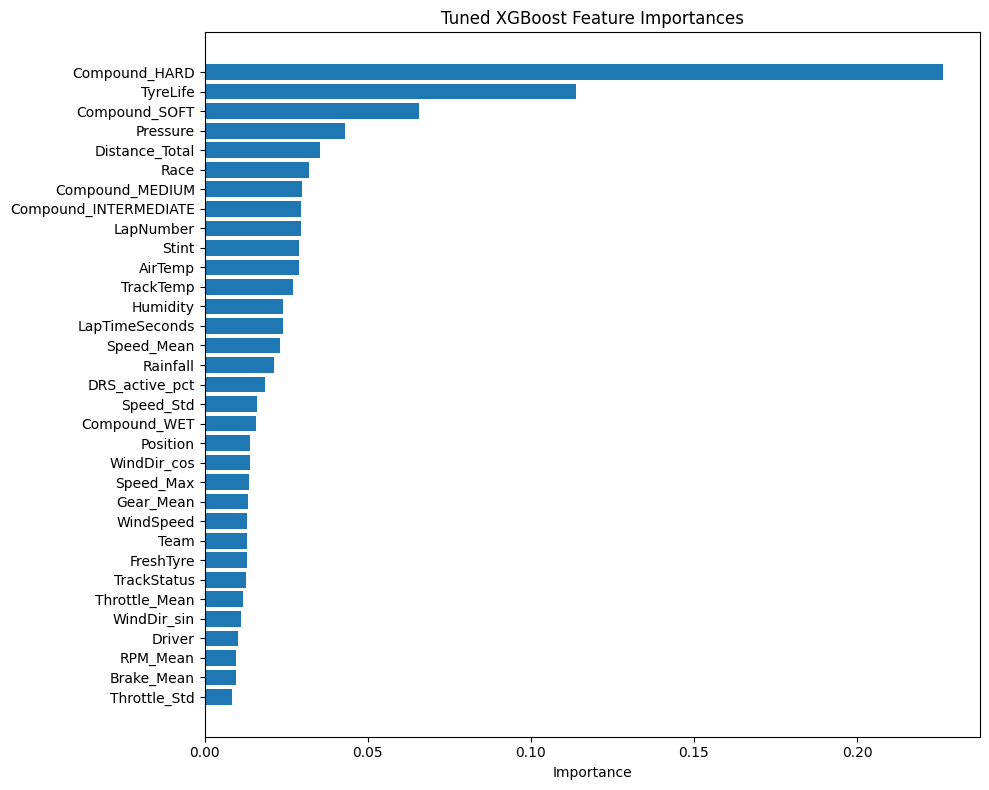

In [146]:
# Get feature importances and sort them
importances_tuned = best_xgb.feature_importances_
indices_tuned = np.argsort(importances_tuned)

plt.figure(figsize=(10, 8))
plt.barh(np.array(X_train.columns)[indices_tuned], importances_tuned[indices_tuned])
plt.title("Tuned XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Result: Poor generalization<br>
Pivot to classification problem, trying to predict whether pit in 5 laps.

#### Reframe as classification task

In [147]:
df_encoded_copy = df_encoded.copy()

In [148]:
# Binary label: 1 if pitting in next 5 laps (including this lap), else 0
df_encoded_copy['PitNext5'] = (df_encoded_copy['LapsTilPit'] <= 5).astype(int)

In [155]:
df_encoded_copy['PitNext5'].value_counts()

PitNext5
0    62811
1    19390
Name: count, dtype: int64

In [149]:
# Train, val, test split
train_df_cl = df_encoded_copy[df_encoded_copy['Year'].isin([2022, 2023])]
val_df_cl   = df_encoded_copy[df_encoded_copy['Year'] == 2024]
test_df_cl  = df_encoded_copy[df_encoded_copy['Year'] == 2025]

In [150]:
# Split sets into features and target
feature_cols = [col for col in train_df_cl.columns if col not in ['LapsTilPit', 'Year', 'PitNext5']]

# Training set
X_train_cl = train_df_cl[feature_cols]
y_train_cl = train_df_cl['PitNext5']

# Validation set
X_val_cl = val_df_cl[feature_cols]
y_val_cl = val_df_cl['PitNext5']

# Test set
X_test_cl = test_df_cl[feature_cols]
y_test_cl = test_df_cl['PitNext5']

In [151]:
print(X_train_cl.shape)
print(y_train_cl.shape)
print(X_val_cl.shape)
print(y_val_cl.shape)
print(X_test_cl.shape)
print(y_test_cl.shape)

(47033, 33)
(47033,)
(26381, 33)
(26381,)
(8787, 33)
(8787,)


#### Train XGBoost classifier model

In [159]:
# Train
xgb_base_cl = XGBClassifier()
xgb_base_cl.fit(X_train_cl, y_train_cl)

# Predict
y_val_pred_cl = xgb_base_cl.predict(X_val_cl)

# Evaluate
print("XGBoost Classifier Validation Set Performance:\n")
print(confusion_matrix(y_val_cl, y_val_pred_cl))
print(classification_report(y_val_cl, y_val_pred_cl))

XGBoost Classifier Validation Set Performance:

[[17133  3309]
 [ 2105  3834]]
              precision    recall  f1-score   support

           0       0.89      0.84      0.86     20442
           1       0.54      0.65      0.59      5939

    accuracy                           0.79     26381
   macro avg       0.71      0.74      0.72     26381
weighted avg       0.81      0.79      0.80     26381



#### Tune classifier model

In [161]:
# Class imbalance -> calculate ratio of negative to positive class
ratio = (y_train_cl == 0).sum() / (y_train_cl == 1).sum()
ratio

np.float64(3.123169983343561)

In [162]:
param_grid_cl = {
    'n_estimators': [100, 200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'scale_pos_weight': [ratio, ratio*0.8, ratio*1.2],
}

In [185]:
search_cl = RandomizedSearchCV(
    xgb_base_cl,
    param_distributions=param_grid_cl,
    n_iter=60,
    scoring='f1_weighted',
    cv=3,
    verbose=1,
    random_state=111,
    n_jobs=-1
)
search_cl.fit(X_train_cl, y_train_cl)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           num_parallel_tree=None, ...),
                   n_iter=60, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.9, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 6, 8],
                                        'n_estimators': [100, 200, 400],
                                        'scale_pos_weight': [np.float64(3.123169983343561),
                                                             np.float64(2.498535986674849),
                                                             np.float64(3.7478039800122733)],
                                        'subsample': [0.7, 0.9, 1.0]},
                   random_state=111, scoring='f1_weighted', verbose=1)

In [186]:
best_xgb_cl = search_cl.best_estimator_
y_val_pred_cl_best = best_xgb_cl.predict(X_val_cl)

print(search_cl.best_params_)
print(confusion_matrix(y_val_cl, y_val_pred_cl_best))
print(classification_report(y_val_cl, y_val_pred_cl_best))

{'subsample': 1.0, 'scale_pos_weight': np.float64(2.498535986674849), 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
[[16857  3585]
 [ 1786  4153]]
              precision    recall  f1-score   support

           0       0.90      0.82      0.86     20442
           1       0.54      0.70      0.61      5939

    accuracy                           0.80     26381
   macro avg       0.72      0.76      0.73     26381
weighted avg       0.82      0.80      0.81     26381



#### Create more bins

In [190]:
def pit_bin(laps_til_pit):
    if laps_til_pit <= 5:
        return 0
    elif laps_til_pit <= 10:
        return 1
    elif laps_til_pit <= 15:
        return 2
    else:
        return 3

df_encoded_copy['PitBins'] = df_encoded_copy['LapsTilPit'].apply(pit_bin)

In [191]:
print(df_encoded_copy['PitBins'].value_counts().sort_index())

PitBins
0    19390
1    17899
2    15075
3    29837
Name: count, dtype: int64


In [196]:
# Train, val, test split
train_df_bins = df_encoded_copy[df_encoded_copy['Year'].isin([2022, 2023])]
val_df_bins   = df_encoded_copy[df_encoded_copy['Year'] == 2024]
test_df_bins  = df_encoded_copy[df_encoded_copy['Year'] == 2025]

In [197]:
# Split sets into features and target
feature_cols = [col for col in train_df_bins.columns if col not in ['LapsTilPit', 'Year', 'PitNext5', 'PitBins']]

# Training set
X_train_bins = train_df_bins[feature_cols]
y_train_bins = train_df_bins['PitBins']

# Validation set
X_val_bins = val_df_bins[feature_cols]
y_val_bins = val_df_bins['PitBins']

# Test set
X_test_bins = test_df_bins[feature_cols]
y_test_bins = test_df_bins['PitBins']

#### Train XGB multiclass model

In [ ]:
# Train
xgb_multi = XGBClassifier(num_class=4)
xgb_multi.fit(X_train_bins, y_train_bins)

# Predict
y_val_pred_bins = xgb_multi.predict(X_val_bins)

# Evaluate
print("XGBoost Multiclass Validation Set Performance:\n")
print(confusion_matrix(y_val_bins, y_val_pred_bins))
print(classification_report(y_val_bins, y_val_pred_bins))

XGBoost Multiclass Validation Set Performance:

[[4366  669  214  690]
 [2028 2068  410  979]
 [1304  796 1156 1402]
 [1535  968  857 6939]]
              precision    recall  f1-score   support

           0       0.47      0.74      0.58      5939
           1       0.46      0.38      0.41      5485
           2       0.44      0.25      0.32      4658
           3       0.69      0.67      0.68     10299

    accuracy                           0.55     26381
   macro avg       0.52      0.51      0.50     26381
weighted avg       0.55      0.55      0.54     26381



In [205]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

In [206]:
search_mc = RandomizedSearchCV(
    estimator=xgb_multi,
    param_distributions=param_grid,
    n_iter=60,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=111
)
search_mc.fit(X_train_bins, y_train_bins)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_con...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_class=4, ...),
                   n_iter=60, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.9, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.9, 1.0]},
                   random_state=111, scoring='f1_macro', verbose=1)

In [207]:
best_xgb_multi = search_mc.best_estimator_
y_val_pred_best = best_xgb_multi.predict(X_val_bins)

print("Best parameters:", search_mc.best_params_)
print(confusion_matrix(y_val_bins, y_val_pred_best))
print(classification_report(y_val_bins, y_val_pred_best))

Best parameters: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
[[3936  767  191 1045]
 [1577 2066  339 1503]
 [1157  600 1058 1843]
 [1308  715  407 7869]]
              precision    recall  f1-score   support

           0       0.49      0.66      0.57      5939
           1       0.50      0.38      0.43      5485
           2       0.53      0.23      0.32      4658
           3       0.64      0.76      0.70     10299

    accuracy                           0.57     26381
   macro avg       0.54      0.51      0.50     26381
weighted avg       0.56      0.57      0.55     26381



In [208]:
y_val_test_best = best_xgb_multi.predict(X_test_bins)

print("Best parameters:", search_mc.best_params_)
print(confusion_matrix(y_test_bins, y_val_test_best))
print(classification_report(y_test_bins, y_val_test_best))

Best parameters: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
[[1401  239   49  355]
 [ 721  592   92  529]
 [ 508  292  209  588]
 [ 538  225  269 2180]]
              precision    recall  f1-score   support

           0       0.44      0.69      0.54      2044
           1       0.44      0.31      0.36      1934
           2       0.34      0.13      0.19      1597
           3       0.60      0.68      0.64      3212

    accuracy                           0.50      8787
   macro avg       0.45      0.45      0.43      8787
weighted avg       0.48      0.50      0.47      8787




--- WEIGHT ---


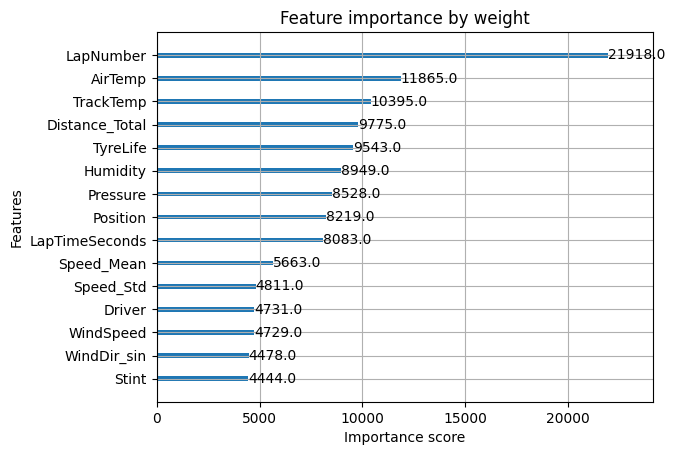


--- GAIN ---


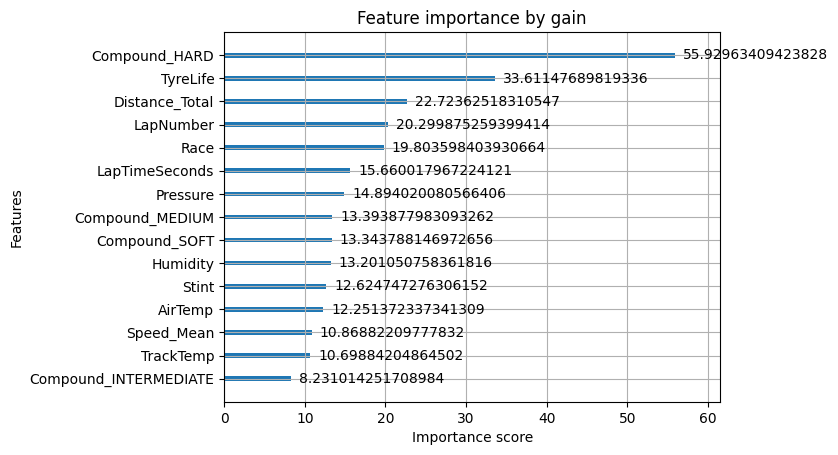


--- COVER ---


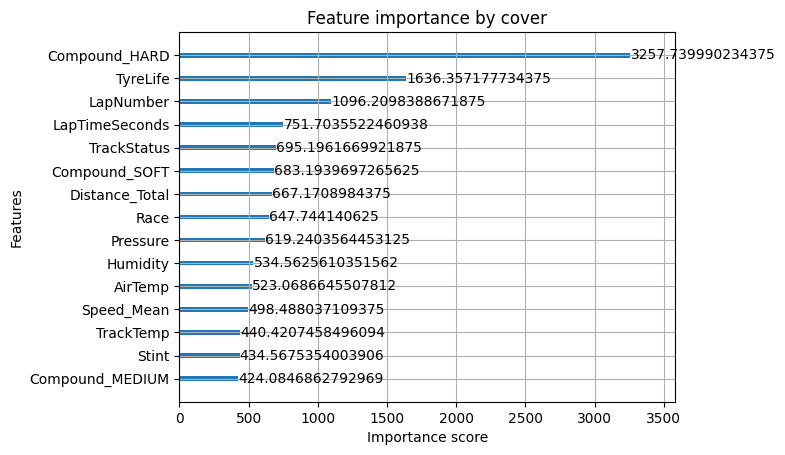

In [212]:
from xgboost import plot_importance

for t in ['weight', 'gain', 'cover']:
    print(f"\n--- {t.upper()} ---")
    plot_importance(best_xgb_multi, importance_type=t, max_num_features=15)
    plt.title(f"Feature importance by {t}")
    plt.show()